In [1]:
import pygame
import os
import sys

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import numpy as np
from PIL import Image
import random
import matplotlib.pyplot as plt
from matplotlib import animation
from collections import deque

print(torch.cuda.is_available())  # 應該為 True
print(torch.version.cuda)         # 應該列出 CUDA 版本
print(torch.backends.cudnn.version())  # cuDNN 版本
script_dir = os.path.join(os.getcwd(), 'space_ship_game_RL')
if script_dir not in sys.path:
    sys.path.append(script_dir)

from setting import *
from game import Game
from Env import SpaceShipEnv

pygame 2.6.1 (SDL 2.28.4, Python 3.12.9)
Hello from the pygame community. https://www.pygame.org/contribute.html
True
12.8
90701


In [2]:
# Hyperparameters
num_episodes = 4000
batch_size = 64
gamma = 0.99
lr = 2.5e-4
epsilon_start, epsilon_end, epsilon_decay = 1, 0.05, 0.999
memory_capacity = 60000  # 100000
target_update_freq = 1000   # 1000 如果學習緩慢

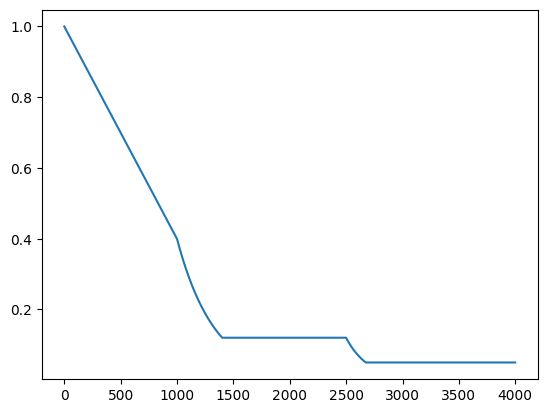

In [3]:
epsilon_list=[]
epsilon=epsilon_start
for episode in range(num_episodes):
    # epsilon = max(epsilon_end, epsilon * epsilon_decay)
        # ----- update epsilon after each episode -----
    if episode < 1000:
        # 線性 1.0 -> 0.4
        epsilon = 1.0 - 0.0006 * episode         # 0.6 / 1000
    elif episode < 2500:
        epsilon = max(0.12, epsilon * 0.997)
    else:
        epsilon = max(0.05, epsilon * 0.995)
    epsilon_list.append(epsilon)
plt.plot(epsilon_list)

In [4]:
class MLPDQN(nn.Module):
    def __init__(self, input_dim, num_actions):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, num_actions)
        )
    def forward(self, x):
        return self.net(x)

In [5]:
class ReplayMemory:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        state = state.detach()
        next_state = next_state.detach()
        # 全存成 numpy，確保在 CPU，減少 GPU->CPU 來回
        self.buffer.append((
            state.cpu().numpy(),
            action,
            reward,
            next_state.cpu().numpy(),
            done
        ))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = map(np.array, zip(*batch))

        # 先在 CPU 轉 tensor，最後一次 to(device)
        states      = torch.as_tensor(states,  dtype=torch.float32)
        actions     = torch.as_tensor(actions, dtype=torch.int64)
        rewards     = torch.as_tensor(rewards, dtype=torch.float32)
        next_states = torch.as_tensor(next_states, dtype=torch.float32)
        dones       = torch.as_tensor(dones, dtype=torch.float32)

        return (states.to(device), actions.to(device), rewards.to(device), next_states.to(device), dones.to(device))

    def __len__(self):
        return len(self.buffer)

In [6]:
# 初始化
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

env = SpaceShipEnv()
num_actions = len(env.action_space)
state_dim    = env._extract_state().shape[0]   # =71

policy_net   = MLPDQN(state_dim, num_actions).to(device)
target_net   = MLPDQN(state_dim, num_actions).to(device)
target_net.load_state_dict(policy_net.state_dict())  # 初始時讓目標網路等於策略網路
target_net.eval()

optimizer = optim.Adam(policy_net.parameters(), lr=lr)
memory = ReplayMemory(memory_capacity)


Using device: cuda


In [ ]:
# trainning loop
if os.path.exists("checkpoint_ep1000.pth"):
    ckpt = torch.load("checkpoint_ep1000.pth", map_location=device)
    policy_net.load_state_dict(ckpt["policy_net"])
    
    target_net.load_state_dict(policy_net.state_dict())   # ★
    target_net.eval()          
    
    optimizer.load_state_dict(ckpt["optimizer"])
    start_episode  = ckpt["episode"] + 1
    total_steps    = ckpt["total_steps"]
    best_avg_score = ckpt["best_avg_score"]
    best_avg_reward= ckpt["best_avg_reward"]
    epsilon = max(0.2, ckpt["epsilon"])                   # ★
    reward_history = ckpt['reward_history']
    score_history = ckpt['score_history']
    score_window  = deque(score_history[-100:],  maxlen=100)  # ★
    reward_window = deque(reward_history[-100:], maxlen=100)  # ★
    print(f"Loaded checkpoint from episode {start_episode}, best_avg_score: {best_avg_score:.2f}, epsilon={epsilon:.3f}")
else:
    start_episode = 0
    total_steps = 0
    best_score = float('-inf')
    epsilon = epsilon_start
    reward_history = []
    score_history = []

    score_window   = deque(maxlen=100)
    reward_window  = deque(maxlen=100)
    best_avg_score = float('-inf')
    best_avg_reward = float('-inf')


# 訓練迴圈 / Training loop
# 每次可以訓練個100步(根據自己的設備與時間調整)，然後下一次都再接續上次的訓練模型接續往下訓練
# You can train for 100 steps each time (adjust according to your own equipment and time),
# and then continue training from the last training model next time.
for episode in range(start_episode, 4000):
    state_np = env.reset()
    state    = torch.tensor(state_np, dtype=torch.float32, device=device)
    total_reward, done = 0.0, False

    while not done:
        # ---------- ε-greedy ----------
        if random.random() < epsilon:
            action = random.randrange(num_actions)
        else:
            with torch.no_grad():
                action = policy_net(state.unsqueeze(0)).argmax(1).item()

        # ---------- 執行動作 ----------
        next_state_np, reward, done, score = env.step(action)
        next_state = torch.tensor(next_state_np, dtype=torch.float32, device=device)

        total_reward += reward
        memory.push(state, action, reward, next_state, done)

        state = next_state

        # ---------- 取 batch 訓練 ----------
        if len(memory) >= batch_size:
            states, actions, rewards, next_states, dones = memory.sample(batch_size)

            with torch.no_grad():
                next_act = policy_net(next_states).argmax(1).unsqueeze(1)       # ★
                next_q   = target_net(next_states).gather(1, next_act).squeeze(1) # ★
                target_q = rewards + gamma * next_q * (1 - dones)              # ★

            current_q = policy_net(states).gather(1, actions.unsqueeze(1)).squeeze(1)
            loss = F.mse_loss(current_q, target_q)
            
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(policy_net.parameters(), 10)
            optimizer.step()

        # ---------- 更新 target ----------
        total_steps += 1
        if total_steps % target_update_freq == 0:
            target_net.load_state_dict(policy_net.state_dict())


    # epsilon = max(epsilon_end, epsilon * epsilon_decay)
    # ----- update epsilon after each episode -----
    if episode < 1000:
        # 線性 1.0 -> 0.4
        epsilon = 1.0 - 0.0006 * episode         # 0.6 / 1000
    elif episode < 2500:
        epsilon = max(0.12, epsilon * 0.997)
    else:
        epsilon = max(0.05, epsilon * 0.995)
    
    reward_history.append(total_reward)
    score_history.append(score)
    
    score_window.append(score)
    reward_window.append(total_reward)

    avg_score  = sum(score_window)  / len(score_window)
    avg_reward = sum(reward_window) / len(reward_window)

    print(f"E{episode+1:4d} | R:{total_reward:7.2f} | S:{score:5.0f} "
          f"| AvgR:{avg_reward:6.1f} | AvgS:{avg_score:6.0f} | ε:{epsilon:.3f}")

    # ---------- ★ 1. 儲存 best 平均 Score ----------
    if avg_score > best_avg_score and len(score_window)==100:
        best_avg_score = avg_score
        torch.save(policy_net.state_dict(), "best_avg_score.pth")
        print(f"  ↑ New best 100-avg SCORE: {best_avg_score:.1f} saved.")

    # ---------- ★ 2. 儲存 best 平均 Reward ----------
    if avg_reward > best_avg_reward and len(reward_window)==100:
        best_avg_reward = avg_reward
        torch.save(policy_net.state_dict(), "best_avg_reward.pth")
        print(f"  ↑ New best 100-avg REWARD: {best_avg_reward:.1f} saved.")

    # ---------- ★ 3. 每 50 集完整 checkpoint ----------
    if (episode + 1) % 50 == 0:
        ckpt_path = f"checkpoint_ep{episode+1:04d}.pth"
        torch.save({
            "policy_net": policy_net.state_dict(),
            "target_net": target_net.state_dict(),
            "optimizer":  optimizer.state_dict(),
            "epsilon":    epsilon,
            "episode":    episode,
            "total_steps": total_steps,
            "best_avg_score":  best_avg_score,
            "best_avg_reward": best_avg_reward,
            'reward_history': reward_history,
            'score_history': score_history,
        }, ckpt_path)

        print(f"  ⌁ 50-ep checkpoint saved to {ckpt_path}")

env.close()

E   1 | R: -68.82 | S:  394 | AvgR: -68.8 | AvgS:   394 | ε:1.000
E   2 | R:  -4.05 | S:  330 | AvgR: -36.4 | AvgS:   362 | ε:0.999
E   3 | R:   9.01 | S:  432 | AvgR: -21.3 | AvgS:   385 | ε:0.999
E   4 | R: 285.33 | S:  780 | AvgR:  55.4 | AvgS:   484 | ε:0.998
E   5 | R:-228.98 | S:   94 | AvgR:  -1.5 | AvgS:   406 | ε:0.998
E   6 | R: -89.88 | S:  286 | AvgR: -16.2 | AvgS:   386 | ε:0.997
E   7 | R:-139.14 | S:  296 | AvgR: -33.8 | AvgS:   373 | ε:0.996
E   8 | R:  80.12 | S:  554 | AvgR: -19.6 | AvgS:   396 | ε:0.996
E   9 | R: -26.58 | S:  320 | AvgR: -20.3 | AvgS:   387 | ε:0.995
E  10 | R:  77.70 | S:  600 | AvgR: -10.5 | AvgS:   409 | ε:0.995
E  11 | R: -55.44 | S:  264 | AvgR: -14.6 | AvgS:   395 | ε:0.994
E  12 | R: -85.59 | S:  348 | AvgR: -20.5 | AvgS:   392 | ε:0.993
E  13 | R: 140.51 | S:  474 | AvgR:  -8.1 | AvgS:   398 | ε:0.993
E  14 | R:   5.86 | S:  300 | AvgR:  -7.1 | AvgS:   391 | ε:0.992
E  15 | R: -80.55 | S:  236 | AvgR: -12.0 | AvgS:   381 | ε:0.992
E  16 | R:

In [ ]:
from scipy.ndimage import gaussian_filter1d

reward_smooth = gaussian_filter1d(reward_history, sigma=50)
score_smooth = gaussian_filter1d(score_history, sigma=50)

# 畫圖
# plt.figure(figsize=(10, 5))
plt.plot(reward_history, label='Total Reward', alpha=0.8)
plt.plot(score_history, label='Score', alpha=0.8)
plt.plot(reward_smooth, label='Smoothed Total Reward', linewidth=2)
plt.plot(score_smooth, label='Smoothed Score', linewidth=2)

plt.legend(loc='upper left')
plt.xlabel("Episode")
plt.ylabel("Value")
plt.title("Training Reward Over Episodes")
plt.grid(True)
plt.tight_layout()
# plt.savefig("dqn_training_curve.png")

